In [3]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, re

font_prop = fm.FontProperties(fname=r'C:\Windows\Fonts\malgun.ttf')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
TASK_DIR = os.path.dirname(BASE_DIR)
RES_DIR  = os.path.join(TASK_DIR, 'resources')
OUT_DIR  = os.path.join(TASK_DIR, 'output')
os.makedirs(RES_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
print('환경 준비 완료')

환경 준비 완료


In [4]:
# Wikipedia 매출 기준 세계 최대 기업 목록 스크래핑
URL = 'https://en.wikipedia.org/wiki/List_of_largest_companies_by_revenue'
headers = {'User-Agent': 'Mozilla/5.0 (educational data scraping project)'}
resp = requests.get(URL, headers=headers, timeout=30)
print('HTTP status:', resp.status_code)

soup = BeautifulSoup(resp.text, 'html.parser')
# wikitable 클래스 테이블 중 Rank 컬럼이 있는 첫 번째 테이블 선택
tables = soup.find_all('table', class_='wikitable')
print(f'wikitable 수: {len(tables)}')

target = None
for t in tables:
    headers_row = [th.get_text(strip=True) for th in t.find_all('th')]
    if any('Rank' in h or 'Revenue' in h for h in headers_row):
        target = t
        break
print('테이블 발견:', target is not None)

HTTP status: 200
wikitable 수: 2
테이블 발견: True


In [5]:
# 테이블 파싱 및 정제
rows = []
for tr in target.find_all('tr')[1:]:  # 헤더 제외
    cols = [td.get_text(strip=True) for td in tr.find_all(['td', 'th'])]
    if len(cols) >= 6:
        rows.append(cols)

df = pd.DataFrame(rows)
print('원본 shape:', df.shape)
df.head(3)

원본 shape: (50, 9)


,0,1,2,3,4,5,6,7,8
0,1,Amazon,RetailInformation technology,716,79.9,"1,576,000",United States,,[5]
1,2,Walmart,Retail,713,21.8,"2,100,000",,[6],None
2,3,State Grid Corporation of China,Electricity,545,9.2,"1,361,423",China,,[7]


In [6]:
# 컬럼 정리 및 타입 변환
df.columns = ['순위', '기업명', '산업', '매출(십억USD)', '영업이익(십억USD)', '직원수', '국가'] + list(df.columns[7:])
df = df[['순위', '기업명', '산업', '매출(십억USD)', '영업이익(십억USD)', '직원수', '국가']].copy()

def clean_num(s):
    # 쉼표, 통화기호, 각주 제거 후 숫자 추출
    s = re.sub(r'[\[\]\(\)a-zA-Z,\$]', '', str(s))
    s = s.replace(',', '').strip()
    try: return float(s)
    except: return None

df['순위']           = pd.to_numeric(df['순위'], errors='coerce')
df['매출(십억USD)']  = df['매출(십억USD)'].apply(clean_num)
df['영업이익(십억USD)'] = df['영업이익(십억USD)'].apply(clean_num)
df['직원수']         = df['직원수'].apply(clean_num)
df = df.dropna(subset=['순위', '매출(십억USD)']).sort_values('순위').reset_index(drop=True)

print('정제 후 shape:', df.shape)
print(df.dtypes.to_string())
print()
df.head()

정제 후 shape: (50, 7)
순위               int64
기업명             object
산업              object
매출(십억USD)      float64
영업이익(십억USD)    float64
직원수            float64
국가              object



,순위,기업명,산업,매출(십억USD),영업이익(십억USD),직원수,국가
0,1,Amazon,RetailInformation technology,716.0,79.9,1576000.0,United States
1,2,Walmart,Retail,713.0,21.8,2100000.0,
2,3,State Grid Corporation of China,Electricity,545.0,9.2,1361423.0,China
3,4,Saudi Aramco,Oil and gas,480.0,106.0,73311.0,Saudi Arabia
4,5,China National Petroleum Corporation,476,25.2,1026301.0,NaN,


In [13]:
# 데이터 탐색
# 결측값 현황 DataFrame 출력
display(df.isnull().sum().to_frame('결측값').T)

# 국가 및 산업 분포 상위 8개씩 DataFrame 출력
display(df['국가'].value_counts().head(8).to_frame('국가별 기업수').T)
display(df['산업'].value_counts().head(8).to_frame('산업별 기업수').T)

# 매출(십억USD) 기초 통계 DataFrame 출력
display(df['매출(십억USD)'].describe().to_frame().T.round(1))

,순위,기업명,산업,매출(십억USD),영업이익(십억USD),직원수,국가
결측값,0,0,0,0,0,5,0


국가,,United States,China,Germany,Switzerland,United Kingdom,Saudi Arabia,[10]
국가별 기업수,16,12,7,4,2,2,1,1


산업,Automotive,Healthcare,Oil and gas,Financials,Commodities,Construction,Retail,Information technology
산업별 기업수,7,7,6,6,3,3,3,3


,count,mean,std,min,25%,50%,75%,max
매출(십억USD),50.0,250.4,148.6,4.5,171.2,209.0,322.2,716.0


In [8]:
# 매출 기준 상위 10개 기업
top10 = df.nlargest(10, '매출(십억USD)')[['순위', '기업명', '산업', '매출(십억USD)', '국가']]
print('=== 매출 기준 상위 10개 기업 ===')
print(top10.to_string(index=False))
top10

=== 매출 기준 상위 10개 기업 ===
 순위                             기업명                           산업  매출(십억USD)            국가
  1                          Amazon RetailInformation technology      716.0 United States
  2                         Walmart                       Retail      713.0              
  3 State Grid Corporation of China                  Electricity      545.0         China
  4                    Saudi Aramco                  Oil and gas      480.0  Saudi Arabia
  7                           Apple       Information technology      416.0 United States
  8                        Alphabet       Information technology      402.0              
  9              UnitedHealth Group                   Healthcare      400.0              
 10              Berkshire Hathaway                   Financials      371.0              
 11                      CVS Health                   Healthcare      357.0              
 12                Volkswagen Group                   Automotive      348.0 

,순위,기업명,산업,매출(십억USD),국가
0,1,Amazon,RetailInformation technology,716.0,United States
1,2,Walmart,Retail,713.0,
2,3,State Grid Corporation of China,Electricity,545.0,China
3,4,Saudi Aramco,Oil and gas,480.0,Saudi Arabia
6,7,Apple,Information technology,416.0,United States
7,8,Alphabet,Information technology,402.0,
8,9,UnitedHealth Group,Healthcare,400.0,
9,10,Berkshire Hathaway,Financials,371.0,
10,11,CVS Health,Healthcare,357.0,
11,12,Volkswagen Group,Automotive,348.0,Germany


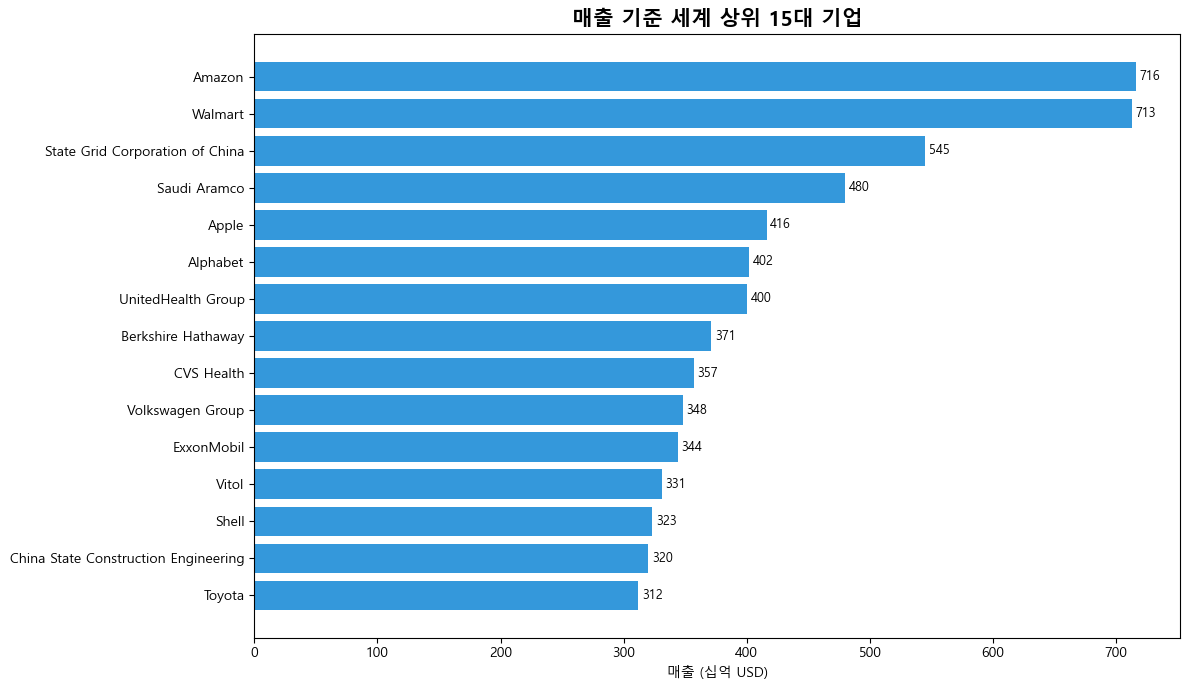

저장: top15_revenue.png


In [9]:
# 매출 기준 상위 15개 기업 막대 차트
top15 = df.nlargest(15, '매출(십억USD)').sort_values('매출(십억USD)')
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15['기업명'], top15['매출(십억USD)'], color='#3498db')
ax.set_title('매출 기준 세계 상위 15대 기업', fontsize=15, fontweight='bold')
ax.set_xlabel('매출 (십억 USD)')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 3, bar.get_y() + bar.get_height()/2, f'{w:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'top15_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: top15_revenue.png')

=== 국가별 기업 수 & 총 매출 ===
                기업수     총매출
국가                         
                 16  3807.6
United States    12  3338.0
China             7  1766.0
Germany           4   861.0
Switzerland       2   548.0
United Kingdom    2   536.0
Saudi Arabia      1   480.0
Japan             1   312.0
Singapore         1   244.0
France            1   218.0
Netherlands       1   204.0
South Korea       1   198.0
[10]              1     9.3


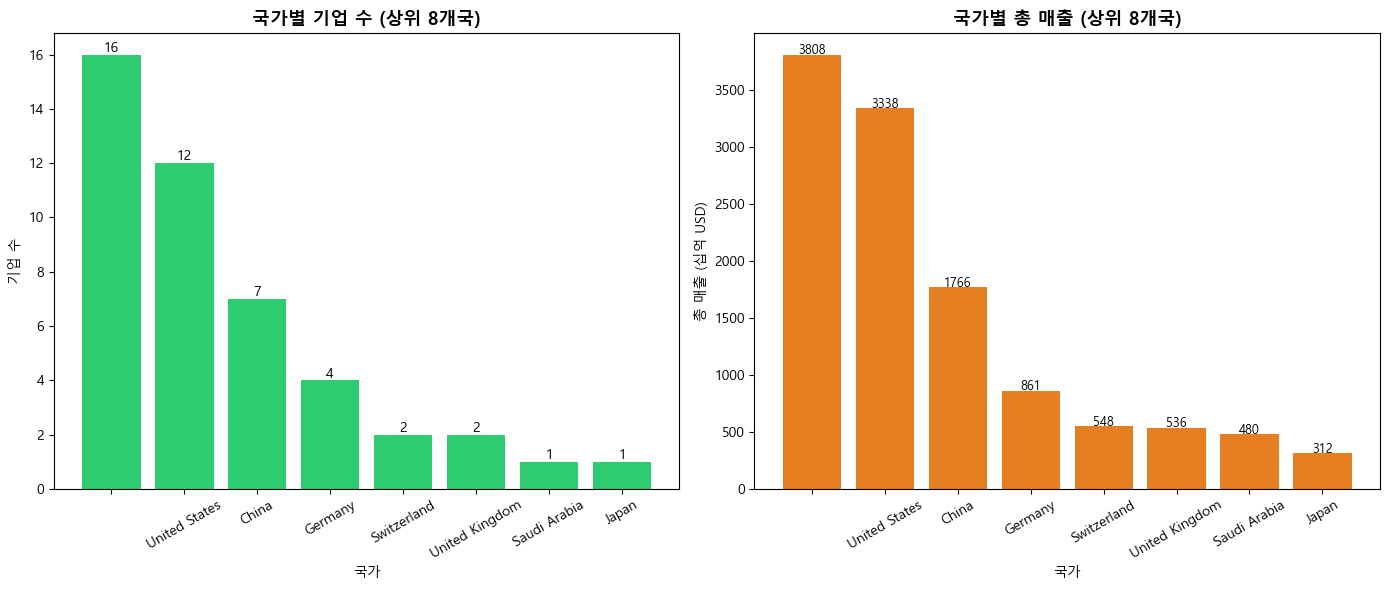

저장: country_analysis.png


In [10]:
# 국가별 분석 — 기업 수 및 총 매출
country_stats = df.groupby('국가').agg(
    기업수=('기업명', 'count'),
    총매출=('매출(십억USD)', 'sum')
).sort_values('총매출', ascending=False).round(1)
print('=== 국가별 기업 수 & 총 매출 ===')
print(country_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_c = country_stats.head(8)
axes[0].bar(top_c.index, top_c['기업수'], color='#2ecc71')
axes[0].set_title('국가별 기업 수 (상위 8개국)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('국가'); axes[0].set_ylabel('기업 수')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(top_c['기업수']):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=10)

axes[1].bar(top_c.index, top_c['총매출'], color='#e67e22')
axes[1].set_title('국가별 총 매출 (상위 8개국)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('국가'); axes[1].set_ylabel('총 매출 (십억 USD)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(top_c['총매출']):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'country_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: country_analysis.png')

=== 산업별 총 매출 ===
                              기업수     총매출
산업                                       
Healthcare                      7  1898.0
Oil and gas                     6  1778.0
Automotive                      7  1544.0
Financials                      6  1329.0
Retail                          3  1135.0
Information technology          3  1099.0
Commodities                     3   792.0
RetailInformation technology    1   716.0
Construction                    3   658.0
Electricity                     1   545.0
Semiconductors                  1   215.0
Electronics                     1   198.0
Conglomerate                    1   177.0
Social media                    1   164.0
Steel                           1   157.0
222                             1    51.4
171                             1    26.5
476                             1    25.2
429                             1     9.3
197                             1     4.5


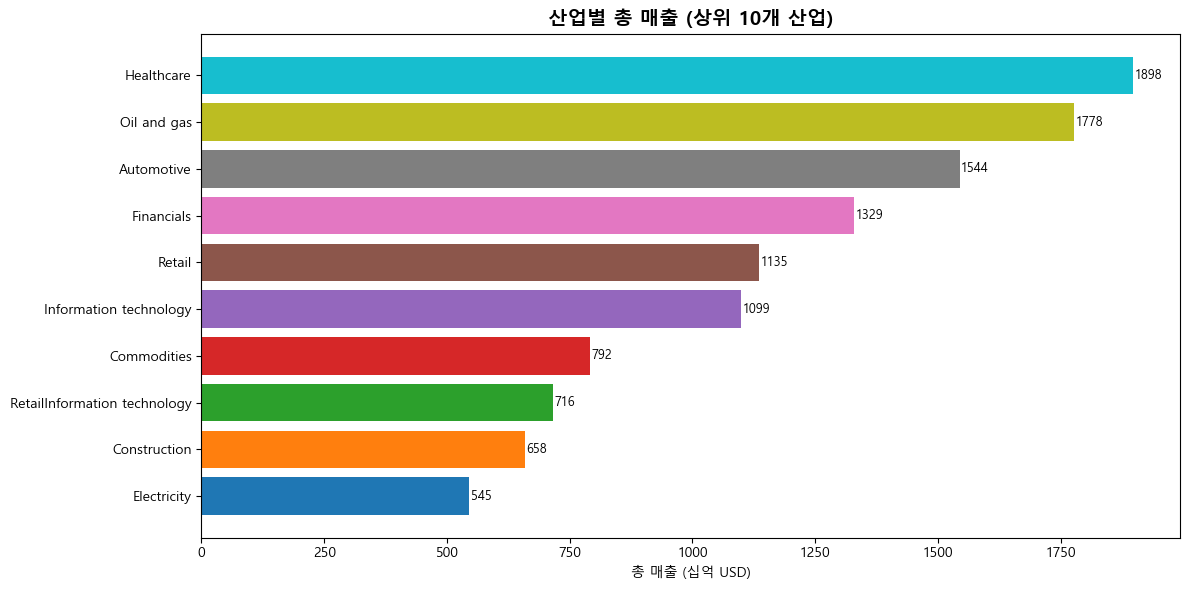

저장: industry_analysis.png


In [11]:
# 산업별 분석 — 총 매출 합계
industry_stats = df.groupby('산업').agg(
    기업수=('기업명', 'count'),
    총매출=('매출(십억USD)', 'sum')
).sort_values('총매출', ascending=False).round(1)
print('=== 산업별 총 매출 ===')
print(industry_stats.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.colormaps.get_cmap('tab10').colors
top_i = industry_stats.head(10).sort_values('총매출')
bars = ax.barh(top_i.index, top_i['총매출'],
               color=[colors[i % len(colors)] for i in range(len(top_i))])
ax.set_title('산업별 총 매출 (상위 10개 산업)', fontsize=14, fontweight='bold')
ax.set_xlabel('총 매출 (십억 USD)')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 3, bar.get_y() + bar.get_height()/2, f'{w:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'industry_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: industry_analysis.png')

In [12]:
# 정제 데이터 CSV 저장
csv_path = os.path.join(RES_DIR, 'largest_companies_scraped.csv')
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'저장 완료: largest_companies_scraped.csv ({len(df)}행)')
print('모든 작업 완료!')

저장 완료: largest_companies_scraped.csv (50행)
모든 작업 완료!
